# PCA Analysis — Fouling State & Crude Property Patterns

**Purpose:** Reduce the 16-dimensional HX fouling state (one U_relative per HX) and operating
feature space to 2–3 interpretable principal components.

**Chemical engineering questions:**
1. What fraction of fouling variation is explained by a single "plant fouling level"?
2. Which HXs drive each principal component?
3. Can crude quality clusters be identified in principal component space?
4. Which features are redundant for ML (high collinearity → can be dropped)?

**Input:** `Feature_calculated.csv` (output of `2_Feature_calculation.ipynb`)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy import stats
import warnings, os
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

FEATURE_PATH = r'C:\Desktop\Bangchak Internship 2026\Data\Feature_calculated.csv'
FIG_DIR = r'C:\Desktop\Bangchak Internship 2026\furnace-optimization\figures\pca'
os.makedirs(FIG_DIR, exist_ok=True)

In [2]:
feature_df = pd.read_csv(FEATURE_PATH, index_col=0, parse_dates=True)
print(f'Loaded: {feature_df.shape[0]} days x {feature_df.shape[1]} columns')
print(f'Date range: {feature_df.index.min().date()} to {feature_df.index.max().date()}')

Loaded: 836 days x 379 columns
Date range: 2024-01-01 to 2026-06-02


In [3]:
# ── Column definitions ────────────────────────────────────────────────────────
HX_LIST = ['E101AB','E101CD','E101EF','E102','E103AB','E104','E105AB',
           'E106AB','E107AB','E108AB','E109AB','E110ABC','E111','E112AB','E112C','E113A']
HX_ORDER = ['E101AB','E101CD','E101EF','E102',
            'E103AB','E104','E105AB',
            'E106AB','E107AB','E108AB','E109AB',
            'E110ABC','E111','E112AB','E112C','E113A']

CRUDE_COLS = [c for c in ['API','SG_15_6C','Visc_50C_cSt','Visc_100C_cSt',
                            'MCRT_pct','Asphaltenes_pct'] if c in feature_df.columns]
FURNACE_COLS = [c for c in ['Q_furnace_kW','excess_air_frac'] if c in feature_df.columns]

UREL_COLS  = [f'{h}_U_relative' for h in HX_LIST if f'{h}_U_relative'  in feature_df.columns]
Q_COLS     = [f'{h}_Q'          for h in HX_LIST if f'{h}_Q'           in feature_df.columns]
TAVG_COLS  = [f'{h}_Tavg'       for h in HX_LIST if f'{h}_Tavg'        in feature_df.columns]
DOD_COLS   = [f'{h}_days_on_duty' for h in HX_LIST if f'{h}_days_on_duty' in feature_df.columns]

print(f'U_relative columns : {len(UREL_COLS)}')
print(f'Crude properties   : {CRUDE_COLS}')

U_relative columns : 16
Crude properties   : ['API', 'SG_15_6C', 'Visc_50C_cSt', 'Visc_100C_cSt', 'MCRT_pct', 'Asphaltenes_pct']


---
## 1. Data Preparation

PCA requires:
1. **Complete cases** — rows with no NaN in the feature set
2. **Standardisation (Z-score)** — mandatory; PCA is sensitive to scale differences
   (U_relative ∈ [0,1] vs. Q ∈ [10⁴ kW] would dominate if unscaled)
3. **Monthly resampling** — day-to-day noise is high; monthly averages reveal structural patterns

We run PCA on **three feature matrices**:
- **Matrix A:** 16 × U_relative (fouling state vector)
- **Matrix B:** Operating conditions (T_avg, Q, mdot per HX)
- **Matrix C:** Crude assay properties

In [4]:
# ── Matrix A: Monthly mean U_relative (16 HX) ────────────────────────────────
monthly_urel = (feature_df[UREL_COLS]
                .resample('ME').mean())
monthly_urel.columns = [c.replace('_U_relative','') for c in monthly_urel.columns]

# Reorder columns by train position
ordered_hx = [h for h in HX_ORDER if h in monthly_urel.columns]
monthly_urel = monthly_urel[ordered_hx]

# Drop months with too many missing HX (need at least 10 of 16)
min_hx = 10
monthly_urel_clean = monthly_urel.dropna(thresh=min_hx)
print(f'Matrix A: {monthly_urel_clean.shape[0]} months x {monthly_urel_clean.shape[1]} HX')
print(f'Missing HX-months: {monthly_urel_clean.isna().sum().sum()} / '
      f'{monthly_urel_clean.shape[0]*monthly_urel_clean.shape[1]}')

# Fill remaining NaN with column median (sparse missing)
mat_A = monthly_urel_clean.fillna(monthly_urel_clean.median())
mat_A.head()

Matrix A: 29 months x 16 HX
Missing HX-months: 33 / 464


,E101AB,E101CD,E101EF,E102,E103AB,E104,E105AB,E106AB,E107AB,E108AB,E109AB,E110ABC,E111,E112AB,E112C,E113A
Timestamp,,,,,,,,,,,,,,,,
2024-01-31,0.962668,0.948115,0.965141,0.960609,0.975839,0.981212,0.981639,0.986888,0.944404,0.947211,0.956006,0.950092,0.959503,0.868635,0.689267,0.900321
2024-02-29,0.921576,0.955944,0.898700,0.937294,0.941576,0.966035,0.970405,0.971550,1.022864,0.852336,0.917412,0.889782,0.912013,0.516456,0.689267,0.770430
2024-03-31,0.879961,0.914577,0.875072,0.934406,0.908298,0.941646,0.924092,0.939285,1.031655,0.819782,0.886118,0.894295,0.881952,0.466221,0.689267,0.775982
2024-04-30,0.828846,0.855105,0.848329,0.885752,0.871287,0.940569,0.878054,0.917649,0.990850,0.770643,0.854197,0.982729,0.845635,0.415674,0.689267,0.731021
2024-06-30,0.869787,0.943364,0.981085,0.962474,0.803804,0.947215,0.962868,0.947919,0.903340,0.609796,0.883657,0.954554,0.952647,0.640851,0.916170,0.952860


In [5]:
# ── Matrix B: Monthly mean operating conditions ───────────────────────────────
op_cols = TAVG_COLS + Q_COLS + DOD_COLS
monthly_op = feature_df[op_cols].resample('ME').mean()
monthly_op_clean = monthly_op.dropna(thresh=int(0.7 * len(op_cols)))
mat_B = monthly_op_clean.fillna(monthly_op_clean.median())
print(f'Matrix B (operating): {mat_B.shape[0]} months x {mat_B.shape[1]} features')

Matrix B (operating): 29 months x 48 features


In [6]:
# ── Matrix C: Daily crude properties ─────────────────────────────────────────
if CRUDE_COLS:
    mat_C_daily = feature_df[CRUDE_COLS].dropna()
    mat_C_monthly = feature_df[CRUDE_COLS].resample('ME').mean().dropna()
    print(f'Matrix C (crude daily)  : {mat_C_daily.shape}')
    print(f'Matrix C (crude monthly): {mat_C_monthly.shape}')
    mat_C_monthly.describe()
else:
    print('No crude property columns available.')

Matrix C (crude daily)  : (836, 6)
Matrix C (crude monthly): (29, 6)


---
## 2. PCA on Fouling State Vector (16 HX U_relative)

**Interpretation guide:**
- **PC1** ≈ "overall plant fouling level" — if all HX foul together, one component explains most variance
- **PC2** ≈ "differential fouling" — upstream vs. downstream HXs behave differently
- **Scree plot** — elbow tells us how many components are needed to describe plant fouling

In [7]:
# ── 2a. PCA on Matrix A ──────────────────────────────────────────────────────
scaler_A = StandardScaler()
X_A = scaler_A.fit_transform(mat_A)

pca_A = PCA()
scores_A = pca_A.fit_transform(X_A)
var_A = pca_A.explained_variance_ratio_
cum_var_A = np.cumsum(var_A)

print('PCA-A Explained variance:')
for i, (v, cv) in enumerate(zip(var_A, cum_var_A)):
    print(f'  PC{i+1}: {v*100:.1f}%  (cumulative: {cv*100:.1f}%)')
    if cv > 0.90:
        print(f'  → {i+1} components explain >90% of fouling state variance')
        break

PCA-A Explained variance:
  PC1: 59.0%  (cumulative: 59.0%)
  PC2: 16.7%  (cumulative: 75.7%)
  PC3: 7.5%  (cumulative: 83.2%)
  PC4: 4.7%  (cumulative: 88.0%)
  PC5: 4.2%  (cumulative: 92.2%)
  → 5 components explain >90% of fouling state variance


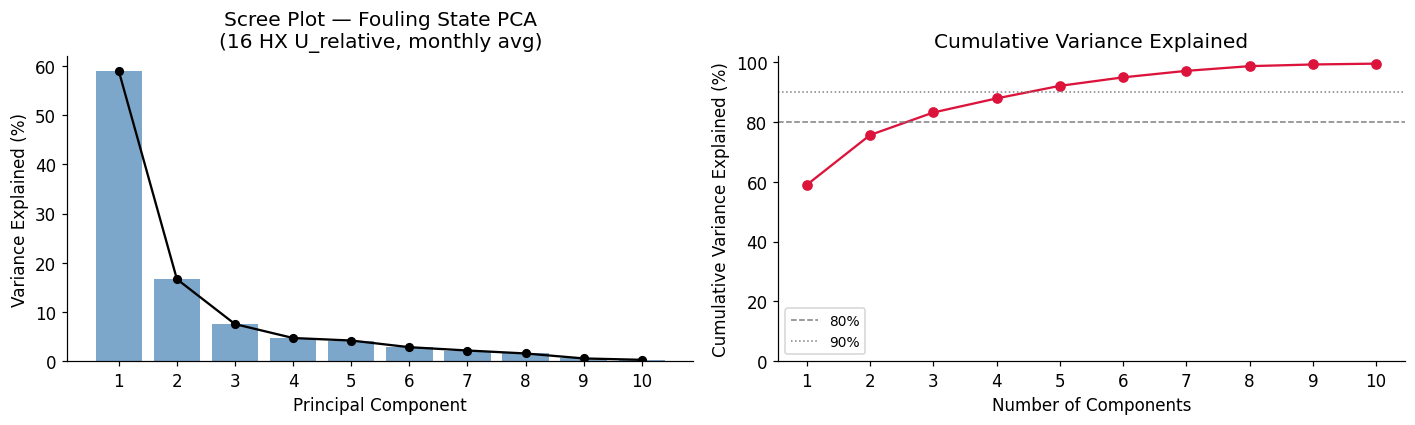


→ 5 PC(s) needed to explain ≥90% of HX fouling state variance
   PC1 alone: 59.0% — dominant, plant-wide fouling signal


In [8]:
# ── 2b. Scree plot ───────────────────────────────────────────────────────────
n_plot = min(10, len(var_A))
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Scree
axes[0].bar(range(1, n_plot+1), var_A[:n_plot]*100, color='steelblue', alpha=0.7)
axes[0].plot(range(1, n_plot+1), var_A[:n_plot]*100, 'ko-', ms=5)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained (%)')
axes[0].set_title('Scree Plot — Fouling State PCA\n(16 HX U_relative, monthly avg)')
axes[0].set_xticks(range(1, n_plot+1))

# Cumulative
axes[1].plot(range(1, n_plot+1), cum_var_A[:n_plot]*100, 'o-', color='crimson', ms=6)
axes[1].axhline(80, color='gray', ls='--', lw=1, label='80%')
axes[1].axhline(90, color='gray', ls=':', lw=1, label='90%')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Explained (%)')
axes[1].set_title('Cumulative Variance Explained')
axes[1].set_xticks(range(1, n_plot+1))
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 102)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '2b_scree_fouling.png'), bbox_inches='tight')
plt.show()

n_90 = np.argmax(cum_var_A >= 0.90) + 1
print(f'\n→ {n_90} PC(s) needed to explain ≥90% of HX fouling state variance')
print(f'   PC1 alone: {var_A[0]*100:.1f}% — '
      f'{"dominant, plant-wide fouling signal" if var_A[0] > 0.4 else "shared with other components"}')

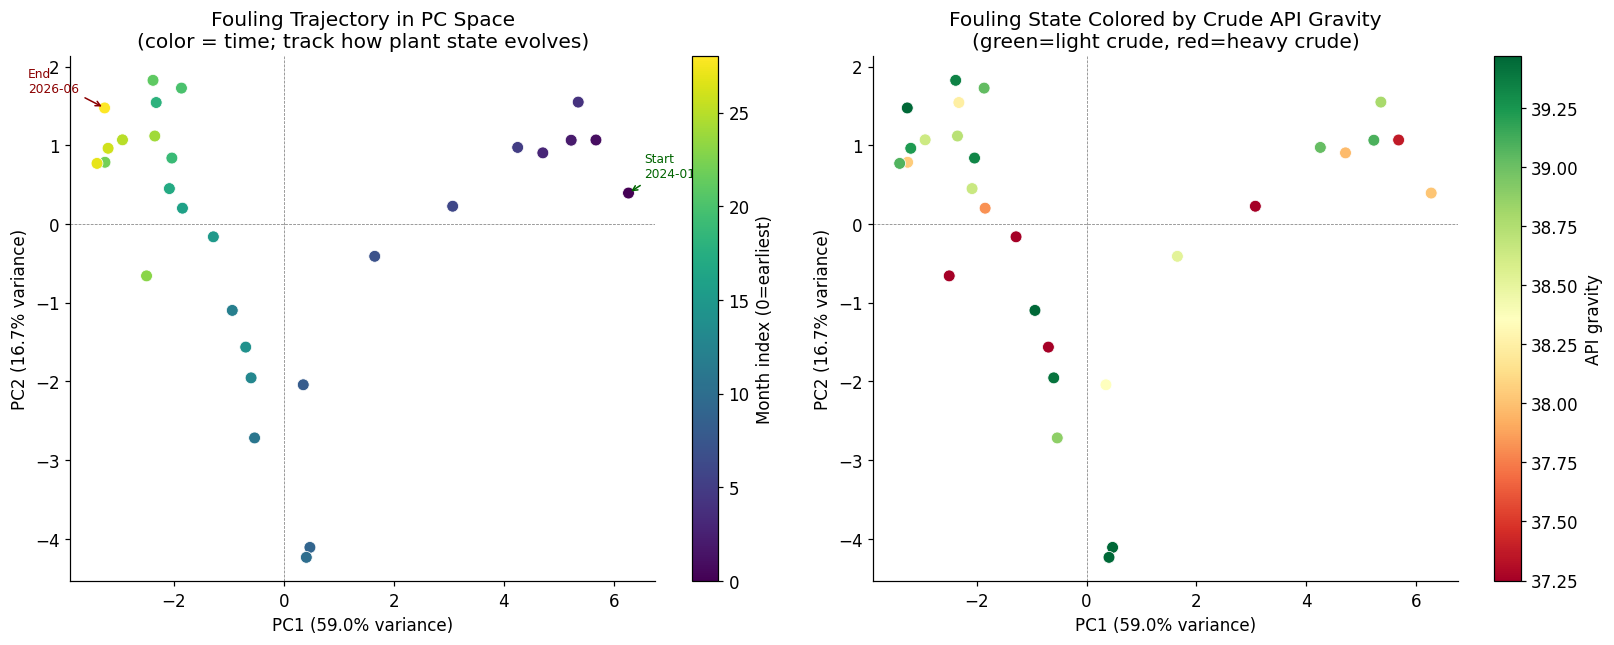

In [9]:
# ── 2c. PC1 vs PC2 score plot — colored by TIME ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

time_idx = np.arange(len(mat_A))  # month index

# Left: color by time
sc = axes[0].scatter(scores_A[:,0], scores_A[:,1], c=time_idx,
                     cmap='viridis', s=60, zorder=3, edgecolors='white', lw=0.5)
plt.colorbar(sc, ax=axes[0], label='Month index (0=earliest)')

# Annotate start and end
axes[0].annotate(f'Start\n{mat_A.index[0].strftime("%Y-%m")}',
                 xy=(scores_A[0,0], scores_A[0,1]),
                 xytext=(10, 10), textcoords='offset points',
                 fontsize=8, color='darkgreen',
                 arrowprops=dict(arrowstyle='->', color='darkgreen', lw=1))
axes[0].annotate(f'End\n{mat_A.index[-1].strftime("%Y-%m")}',
                 xy=(scores_A[-1,0], scores_A[-1,1]),
                 xytext=(-50, 10), textcoords='offset points',
                 fontsize=8, color='darkred',
                 arrowprops=dict(arrowstyle='->', color='darkred', lw=1))

axes[0].set_xlabel(f'PC1 ({var_A[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({var_A[1]*100:.1f}% variance)')
axes[0].set_title('Fouling Trajectory in PC Space\n(color = time; track how plant state evolves)')
axes[0].axhline(0, color='gray', lw=0.5, ls='--')
axes[0].axvline(0, color='gray', lw=0.5, ls='--')

# Right: color by API gravity if available
if 'API' in feature_df.columns:
    api_monthly = feature_df['API'].resample('ME').mean().reindex(mat_A.index)
    sc2 = axes[1].scatter(scores_A[:,0], scores_A[:,1], c=api_monthly,
                          cmap='RdYlGn', s=60, zorder=3, edgecolors='white', lw=0.5,
                          vmin=api_monthly.quantile(0.1), vmax=api_monthly.quantile(0.9))
    plt.colorbar(sc2, ax=axes[1], label='API gravity')
    axes[1].set_title('Fouling State Colored by Crude API Gravity\n'
                      '(green=light crude, red=heavy crude)')
else:
    axes[1].scatter(scores_A[:,0], scores_A[:,1], c='steelblue', s=60)
    axes[1].set_title('PC1 vs PC2 — Fouling State')

axes[1].set_xlabel(f'PC1 ({var_A[0]*100:.1f}% variance)')
axes[1].set_ylabel(f'PC2 ({var_A[1]*100:.1f}% variance)')
axes[1].axhline(0, color='gray', lw=0.5, ls='--')
axes[1].axvline(0, color='gray', lw=0.5, ls='--')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '2c_pca_scores_time_api.png'), bbox_inches='tight')
plt.show()

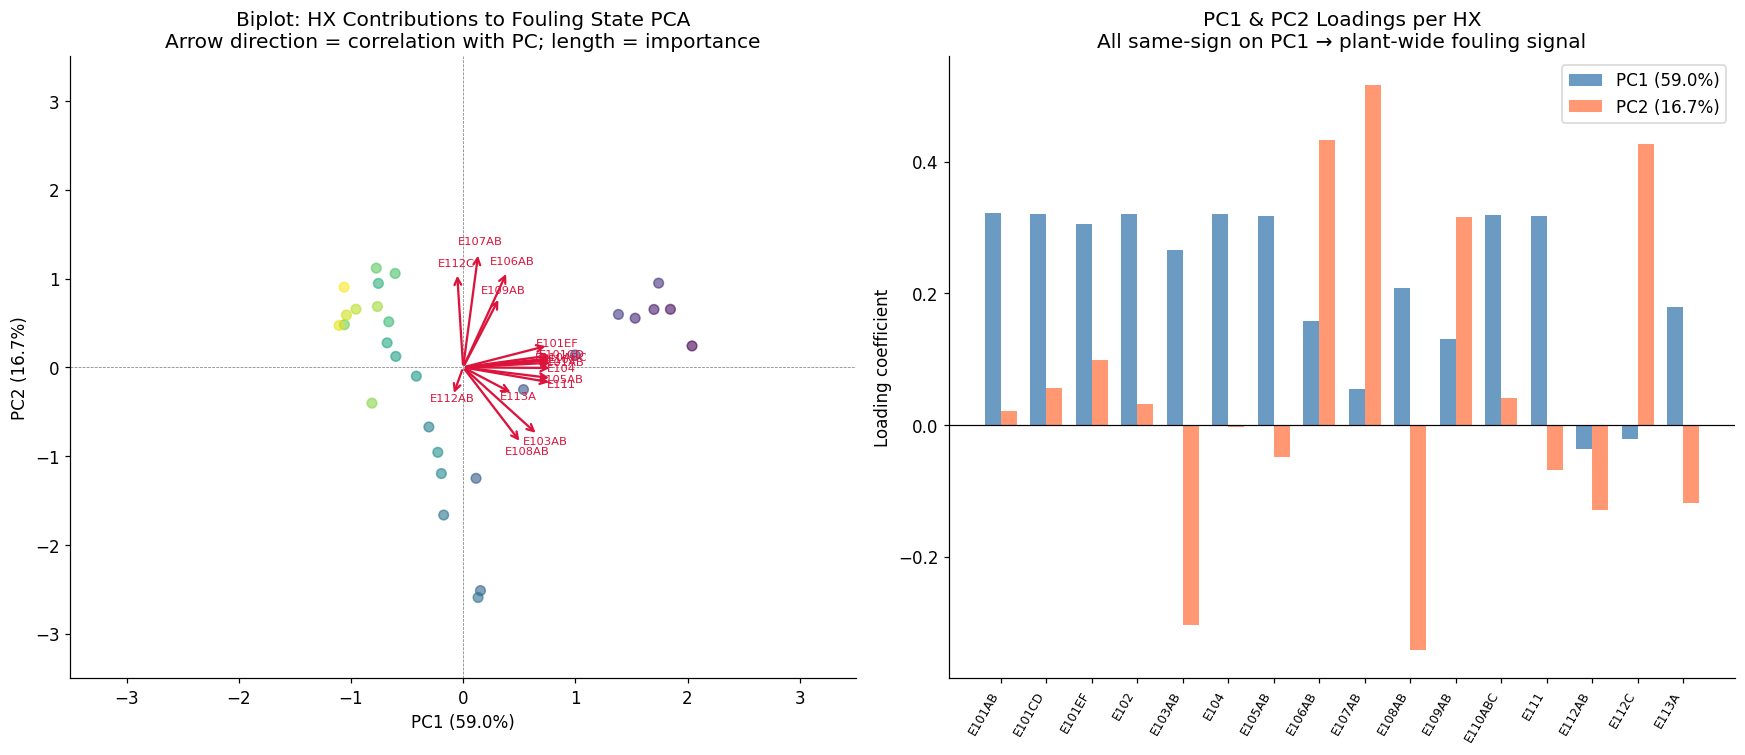

In [10]:
# ── 2d. Biplot — which HXs drive each PC? ────────────────────────────────────
loadings_A = pca_A.components_.T  # shape (n_features, n_components)
feature_names_A = mat_A.columns.tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: biplot (scores + loading arrows)
ax = axes[0]
# Normalise scores for display
scale = np.std(scores_A[:, :2], axis=0)
sc = ax.scatter(scores_A[:,0]/scale[0], scores_A[:,1]/scale[1],
                c=time_idx, cmap='viridis', alpha=0.6, s=40, zorder=2)

# Loading arrows
lscale = 2.5  # arrow length scale
for i, (feat, load) in enumerate(zip(feature_names_A, loadings_A)):
    ax.annotate('', xy=(load[0]*lscale, load[1]*lscale), xytext=(0,0),
                arrowprops=dict(arrowstyle='->', color='crimson', lw=1.5))
    ax.text(load[0]*lscale*1.1, load[1]*lscale*1.1, feat,
            fontsize=7.5, ha='center', va='center', color='crimson')

ax.set_xlabel(f'PC1 ({var_A[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({var_A[1]*100:.1f}%)')
ax.set_title('Biplot: HX Contributions to Fouling State PCA\n'
             'Arrow direction = correlation with PC; length = importance')
ax.axhline(0, color='gray', lw=0.5, ls='--')
ax.axvline(0, color='gray', lw=0.5, ls='--')
ax.set_xlim(-3.5, 3.5); ax.set_ylim(-3.5, 3.5)

# Right: Loading bar chart for PC1 and PC2
x = np.arange(len(feature_names_A))
width = 0.35
axes[1].bar(x - width/2, loadings_A[:,0], width, label=f'PC1 ({var_A[0]*100:.1f}%)',
            color='steelblue', alpha=0.8)
axes[1].bar(x + width/2, loadings_A[:,1], width, label=f'PC2 ({var_A[1]*100:.1f}%)',
            color='coral', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(feature_names_A, rotation=60, ha='right', fontsize=8)
axes[1].set_ylabel('Loading coefficient')
axes[1].set_title('PC1 & PC2 Loadings per HX\n'
                  'All same-sign on PC1 → plant-wide fouling signal')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '2d_biplot.png'), bbox_inches='tight')
plt.show()

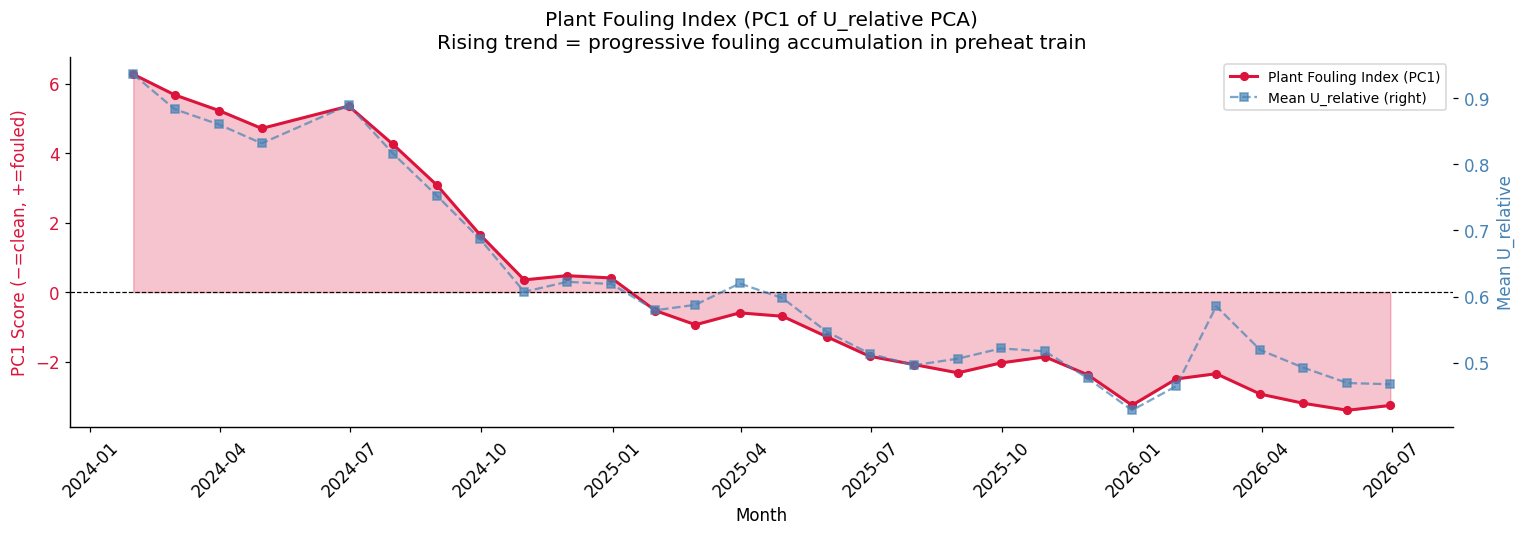

Spearman r(PC1, Mean U_relative) = 0.954  (should be high if PC1 = overall fouling)


In [11]:
# ── 2e. PC1 as "Plant Fouling Index" time series ─────────────────────────────
fig, ax1 = plt.subplots(figsize=(14, 5))

# Flip PC1 sign if positive loadings mean "clean" (high U_relative)
pc1_sign = 1 if loadings_A[:,0].mean() > 0 else -1
plant_fi = pc1_sign * scores_A[:,0]

ax1.fill_between(mat_A.index, plant_fi, alpha=0.25, color='crimson')
ax1.plot(mat_A.index, plant_fi, 'o-', color='crimson', ms=5, lw=2,
         label='Plant Fouling Index (PC1)')
ax1.axhline(0, color='black', lw=0.8, ls='--')
ax1.set_ylabel('PC1 Score (−=clean, +=fouled)', color='crimson')
ax1.tick_params(axis='y', labelcolor='crimson')
ax1.set_xlabel('Month')
ax1.set_title('Plant Fouling Index (PC1 of U_relative PCA)\n'
              'Rising trend = progressive fouling accumulation in preheat train')

# Overlay mean U_relative for validation
ax2 = ax1.twinx()
mean_urel_monthly = mat_A.mean(axis=1)
ax2.plot(mat_A.index, mean_urel_monthly, 's--', color='steelblue', ms=5, lw=1.5,
         alpha=0.7, label='Mean U_relative (right)')
ax2.set_ylabel('Mean U_relative', color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper right', fontsize=9)
ax1.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '2e_plant_fouling_index.png'), bbox_inches='tight')
plt.show()

rho_fi, p_fi = stats.spearmanr(plant_fi, mean_urel_monthly)
print(f'Spearman r(PC1, Mean U_relative) = {rho_fi:.3f}  '
      f'(should be high if PC1 = overall fouling)')

---
## 3. PCA on Operating Conditions

**Purpose:** Identify operating regimes (clusters of similar plant operating states).

**Features:** T_avg, Q (duty), mdot (mass flow), days_on_duty — per HX (standardised)

- Clusters in PC space = distinct operating modes (high throughput, low throughput, turnaround startup)
- Color by month to see seasonal/operational shifts

PC1: 43.5%  PC2: 25.8%  PC3: 8.9%  (cumulative: 78.2%)


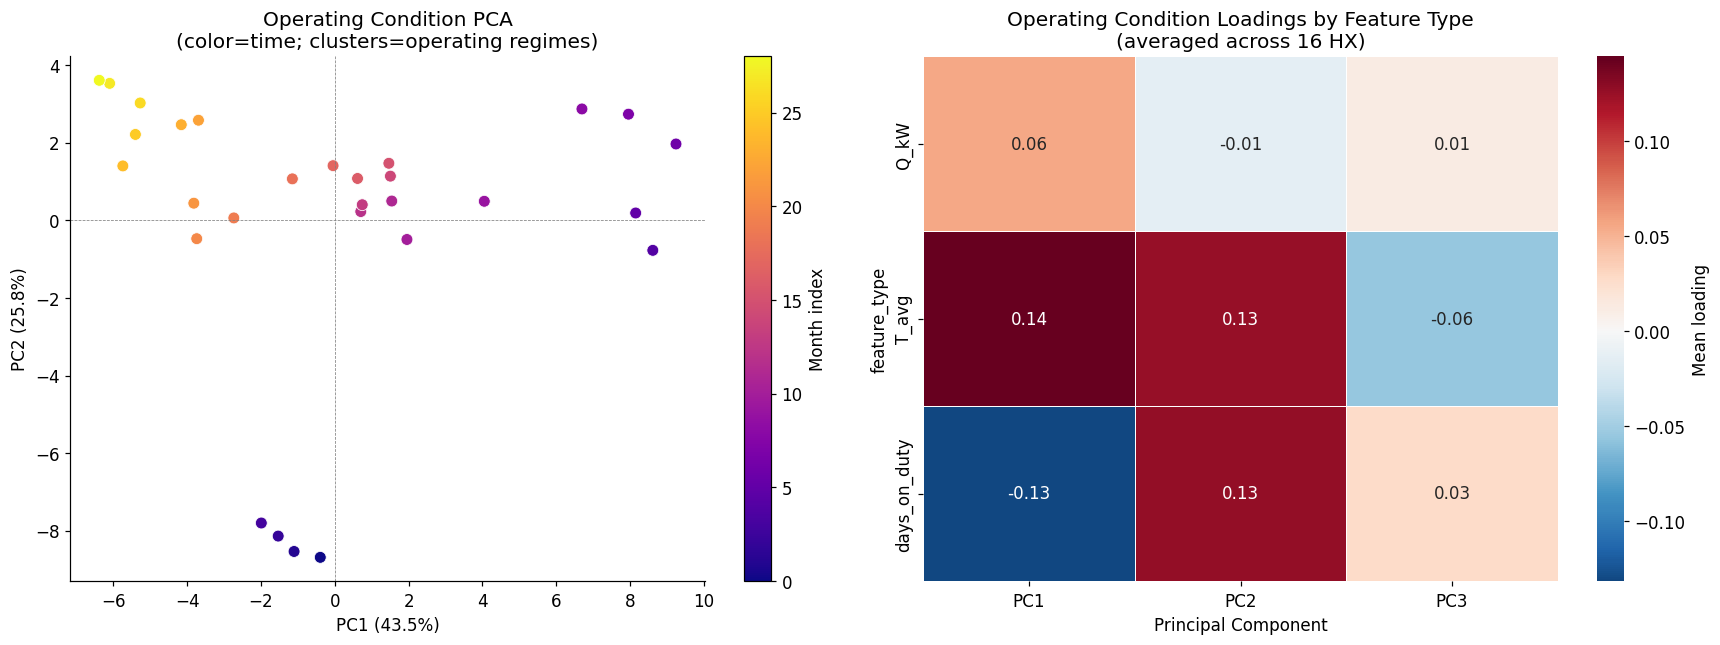

In [12]:
# ── 3. PCA on operating conditions ───────────────────────────────────────────
if mat_B.shape[0] >= 6 and mat_B.shape[1] >= 2:
    scaler_B = StandardScaler()
    X_B = scaler_B.fit_transform(mat_B)
    pca_B = PCA(n_components=min(5, mat_B.shape[1], mat_B.shape[0]))
    scores_B = pca_B.fit_transform(X_B)
    var_B = pca_B.explained_variance_ratio_
    loadings_B = pca_B.components_.T
    feat_names_B = mat_B.columns.tolist()

    print(f'PC1: {var_B[0]*100:.1f}%  PC2: {var_B[1]*100:.1f}%  '
          f'PC3: {var_B[2]*100:.1f}%  (cumulative: {sum(var_B[:3])*100:.1f}%)')

    time_idx_B = np.arange(len(mat_B))

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sc = axes[0].scatter(scores_B[:,0], scores_B[:,1], c=time_idx_B,
                         cmap='plasma', s=60, edgecolors='white', lw=0.5)
    plt.colorbar(sc, ax=axes[0], label='Month index')
    axes[0].set_xlabel(f'PC1 ({var_B[0]*100:.1f}%)')
    axes[0].set_ylabel(f'PC2 ({var_B[1]*100:.1f}%)')
    axes[0].set_title('Operating Condition PCA\n(color=time; clusters=operating regimes)')
    axes[0].axhline(0, color='gray', lw=0.5, ls='--')
    axes[0].axvline(0, color='gray', lw=0.5, ls='--')

    # Loading heatmap for PC1-PC3
    n_show_pc = min(3, len(var_B))
    loading_df_B = pd.DataFrame(loadings_B[:, :n_show_pc],
                                 index=feat_names_B,
                                 columns=[f'PC{i+1}' for i in range(n_show_pc)])
    # Summarise by feature type (T_avg, Q, mdot, days_on_duty)
    loading_df_B['feature_type'] = loading_df_B.index.map(
        lambda c: 'T_avg' if '_Tavg' in c else
                  'Q_kW' if '_Q' in c else
                  'mdot' if '_mdot' in c else
                  'days_on_duty' if '_days' in c else 'other')
    type_loading = loading_df_B.groupby('feature_type').mean()

    sns.heatmap(type_loading, ax=axes[1], cmap='RdBu_r', center=0,
                annot=True, fmt='.2f', linewidths=0.5,
                cbar_kws={'label': 'Mean loading'})
    axes[1].set_title('Operating Condition Loadings by Feature Type\n'
                      '(averaged across 16 HX)')
    axes[1].set_xlabel('Principal Component')

    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, '3_pca_operating.png'), bbox_inches='tight')
    plt.show()
else:
    print(f'Insufficient data for PCA-B: {mat_B.shape}')

---
## 4. Crude Property PCA

**Purpose:** Understand crude feed diversity and connect crude type to fouling.

**Features:** API, SG, Visc_50C, Visc_100C, MCRT, Asphaltenes

- **PC1** of crude PCA ≈ "crude heaviness index" (API ↓, Visc ↑, Asphaltenes ↑ all correlate)
- Distinct clusters = different crude blends fed to the CDU
- Color by Asphaltenes_pct to see which crude cluster is most fouling-prone

Crude PCA — PC1: 56.1%  PC2: 29.9%  (cumulative: 86.0%)


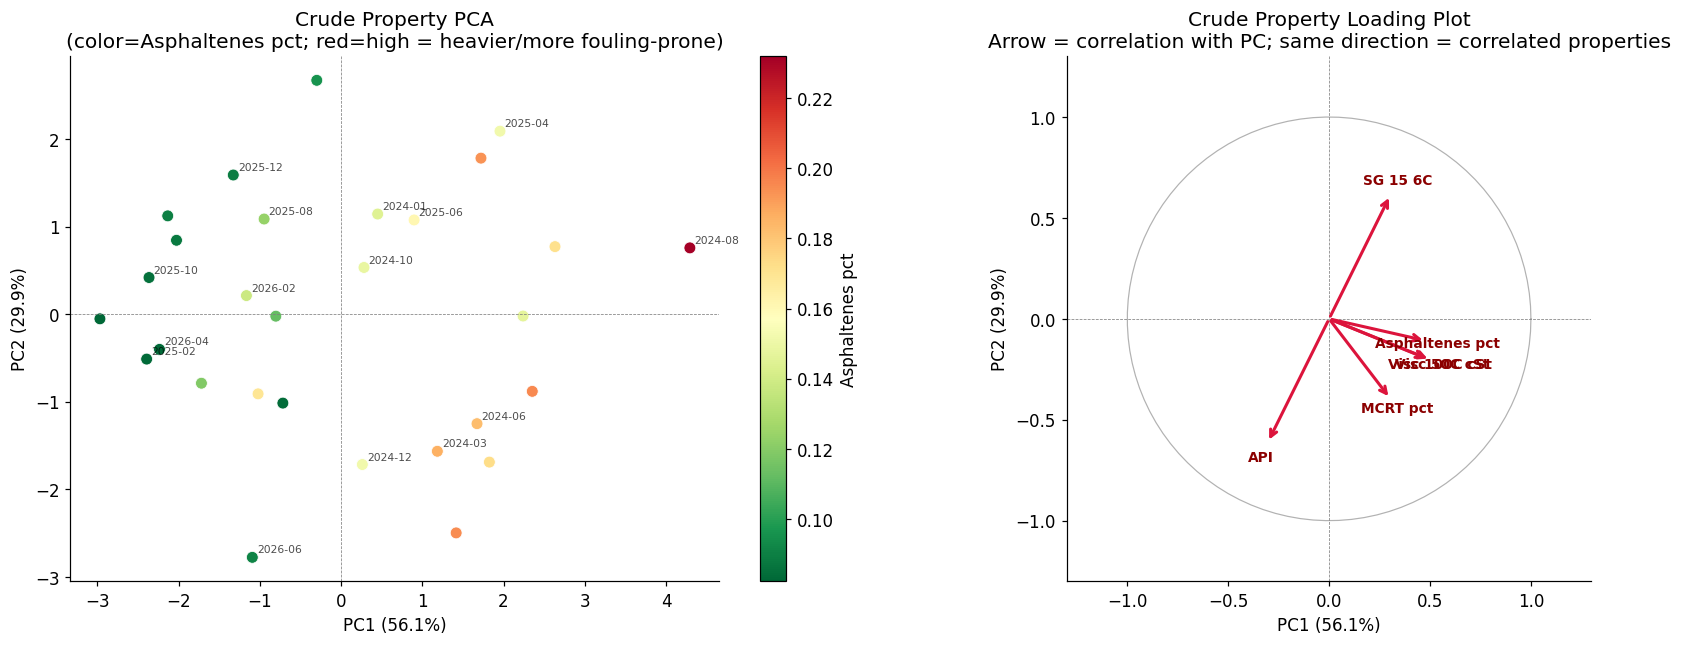


Crude PC1 loadings (positive = correlates with PC1 positive direction):
  API                      : -0.304
  SG_15_6C                 : +0.303
  Visc_50C_cSt             : +0.502
  Visc_100C_cSt            : +0.492
  MCRT_pct                 : +0.303
  Asphaltenes_pct          : +0.479


In [13]:
# ── 4. Crude property PCA ─────────────────────────────────────────────────────
if CRUDE_COLS and len(mat_C_monthly) >= 6:
    scaler_C = StandardScaler()
    X_C = scaler_C.fit_transform(mat_C_monthly)
    n_pc_C = min(len(CRUDE_COLS), len(mat_C_monthly), 5)
    pca_C = PCA(n_components=n_pc_C)
    scores_C = pca_C.fit_transform(X_C)
    var_C = pca_C.explained_variance_ratio_
    loadings_C = pca_C.components_.T

    print(f'Crude PCA — PC1: {var_C[0]*100:.1f}%  PC2: {var_C[1]*100:.1f}%  '
          f'(cumulative: {sum(var_C[:2])*100:.1f}%)')

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Left: scores colored by Asphaltenes (or API)
    color_col = 'Asphaltenes_pct' if 'Asphaltenes_pct' in CRUDE_COLS else CRUDE_COLS[0]
    color_idx = CRUDE_COLS.index(color_col)
    color_vals = mat_C_monthly[color_col] if color_col in mat_C_monthly.columns else None

    if color_vals is not None:
        sc = axes[0].scatter(scores_C[:,0], scores_C[:,1],
                             c=color_vals, cmap='RdYlGn_r', s=60,
                             edgecolors='white', lw=0.5)
        plt.colorbar(sc, ax=axes[0], label=color_col.replace('_',' '))
    else:
        axes[0].scatter(scores_C[:,0], scores_C[:,1], s=60, color='steelblue')

    axes[0].set_xlabel(f'PC1 ({var_C[0]*100:.1f}%)')
    axes[0].set_ylabel(f'PC2 ({var_C[1]*100:.1f}%)')
    axes[0].set_title(f'Crude Property PCA\n(color={color_col.replace("_"," ")}; '
                      f'red=high = heavier/more fouling-prone)')
    axes[0].axhline(0, color='gray', lw=0.5, ls='--')
    axes[0].axvline(0, color='gray', lw=0.5, ls='--')

    # Annotate months on scatter
    for i, (date, sx, sy) in enumerate(zip(mat_C_monthly.index, scores_C[:,0], scores_C[:,1])):
        if i % max(1, len(mat_C_monthly)//12) == 0:
            axes[0].annotate(date.strftime('%Y-%m'), (sx, sy),
                             fontsize=7, alpha=0.7,
                             xytext=(3, 3), textcoords='offset points')

    # Right: loading plot (arrows)
    for i, (feat, load) in enumerate(zip(CRUDE_COLS, loadings_C)):
        axes[1].annotate('', xy=(load[0], load[1]), xytext=(0,0),
                         arrowprops=dict(arrowstyle='->', color='crimson', lw=2))
        axes[1].text(load[0]*1.12, load[1]*1.12, feat.replace('_',' '),
                     fontsize=9, ha='center', va='center', color='darkred', fontweight='bold')

    # Unit circle
    theta = np.linspace(0, 2*np.pi, 100)
    axes[1].plot(np.cos(theta), np.sin(theta), 'k-', lw=0.8, alpha=0.3)
    axes[1].set_xlim(-1.3, 1.3); axes[1].set_ylim(-1.3, 1.3)
    axes[1].set_xlabel(f'PC1 ({var_C[0]*100:.1f}%)')
    axes[1].set_ylabel(f'PC2 ({var_C[1]*100:.1f}%)')
    axes[1].set_title('Crude Property Loading Plot\n'
                      'Arrow = correlation with PC; same direction = correlated properties')
    axes[1].axhline(0, color='gray', lw=0.5, ls='--')
    axes[1].axvline(0, color='gray', lw=0.5, ls='--')
    axes[1].set_aspect('equal')

    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, '4_pca_crude.png'), bbox_inches='tight')
    plt.show()

    print('\nCrude PC1 loadings (positive = correlates with PC1 positive direction):')
    for feat, load in zip(CRUDE_COLS, loadings_C[:,0]):
        print(f'  {feat:25s}: {load:+.3f}')
else:
    print('Insufficient crude property data for PCA.')

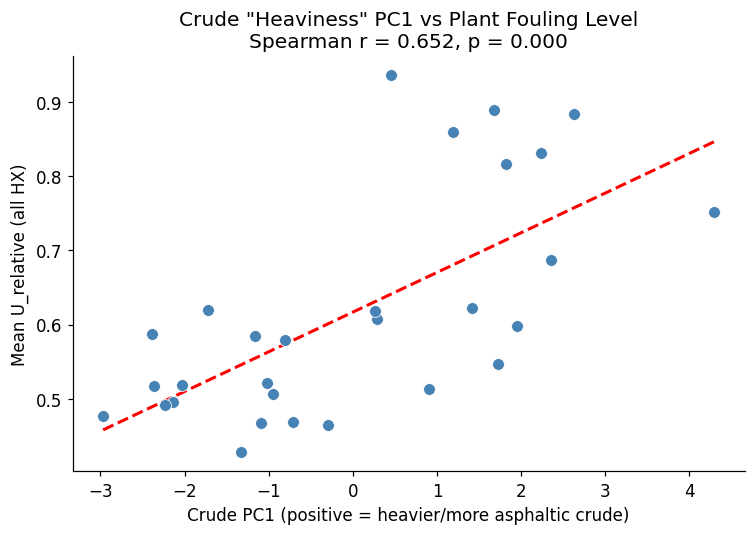

In [14]:
# ── 4b. Connect crude PC1 to mean fouling state ──────────────────────────────
if CRUDE_COLS and len(mat_C_monthly) >= 6:
    crude_pc1 = scores_C[:, 0]
    # Align with fouling data on same months
    idx_common = mat_C_monthly.index.intersection(mat_A.index)
    if len(idx_common) >= 6:
        crude_pc1_aligned = pd.Series(crude_pc1, index=mat_C_monthly.index).reindex(idx_common)
        mean_urel_aligned  = mat_A.mean(axis=1).reindex(idx_common)

        rho_crude, pval_crude = stats.spearmanr(crude_pc1_aligned.dropna(),
                                                mean_urel_aligned.dropna())
        fig, ax = plt.subplots(figsize=(7, 5))
        ax.scatter(crude_pc1_aligned, mean_urel_aligned, s=60, c='steelblue',
                   edgecolors='white', lw=0.5, zorder=3)
        slope, intercept, *_ = stats.linregress(crude_pc1_aligned.dropna(),
                                                mean_urel_aligned.dropna())
        xr = np.linspace(crude_pc1_aligned.min(), crude_pc1_aligned.max(), 100)
        ax.plot(xr, slope*xr+intercept, 'r--', lw=2)
        ax.set_xlabel('Crude PC1 (positive = heavier/more asphaltic crude)')
        ax.set_ylabel('Mean U_relative (all HX)')
        ax.set_title(f'Crude "Heaviness" PC1 vs Plant Fouling Level\n'
                     f'Spearman r = {rho_crude:.3f}, p = {pval_crude:.3f}')
        plt.tight_layout()
        plt.savefig(os.path.join(FIG_DIR, '4b_crude_pc1_vs_fouling.png'), bbox_inches='tight')
        plt.show()

---
## 5. PCA for ML Feature Selection — Full Feature Space

**Purpose:** Identify redundant features before model training.

Features with very similar PC loadings (pointing in same direction) are collinear — keeping only one
reduces model complexity without losing predictive power.

**Feature matrix:** days_on_duty + Q + Tavg + Cp (all HX) + crude properties + furnace

Full ML feature matrix: 836 days x 72 features


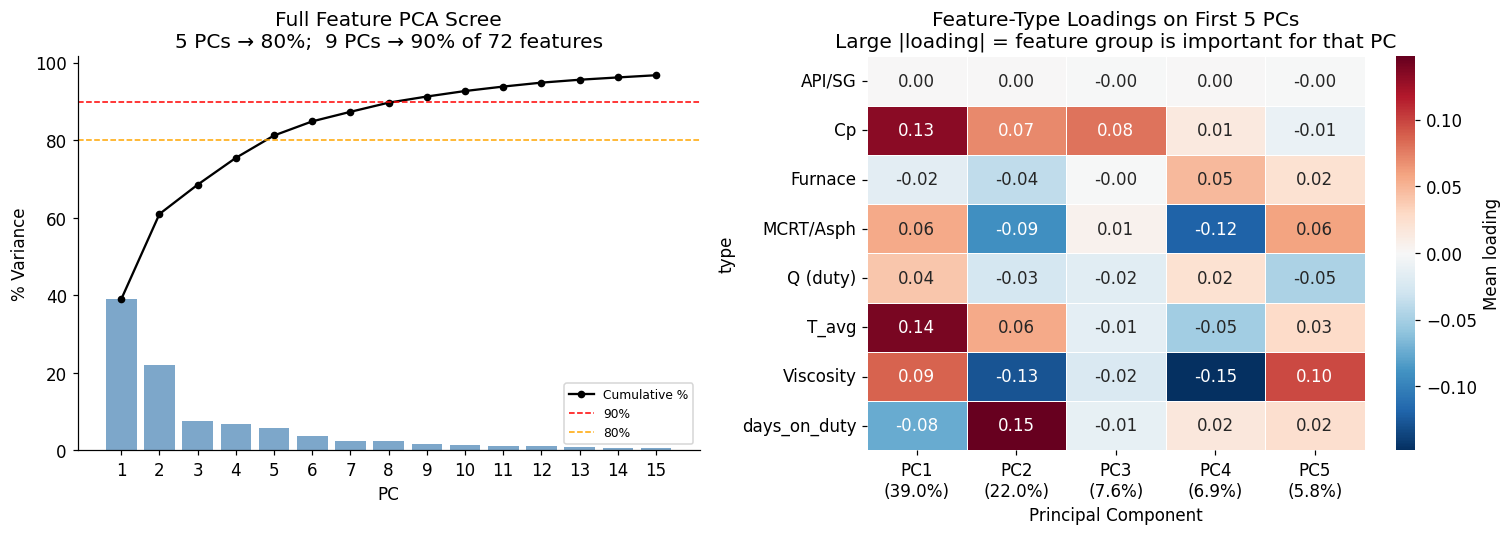


ML Feature Reduction Guidance:
  Original features : 72
  PCs for 80% var   : 5  (safe lower bound for ML)
  PCs for 90% var   : 9

  Recommendation: Keep all feature types — they each occupy different PCs.
  Drop: intra-type duplicates (e.g., Visc_50C and Visc_100C are likely collinear).


In [15]:
# ── 5. Full feature PCA ───────────────────────────────────────────────────────
ml_cols = (DOD_COLS + Q_COLS + TAVG_COLS +
           [f'{h}_Cp' for h in HX_LIST if f'{h}_Cp' in feature_df.columns] +
           CRUDE_COLS + FURNACE_COLS)
ml_cols = [c for c in ml_cols if c in feature_df.columns]

ml_daily = feature_df[ml_cols].dropna()
print(f'Full ML feature matrix: {ml_daily.shape[0]} days x {ml_daily.shape[1]} features')

if ml_daily.shape[0] >= 20 and ml_daily.shape[1] >= 4:
    scaler_ML = StandardScaler()
    X_ML = scaler_ML.fit_transform(ml_daily)
    pca_ML = PCA()
    pca_ML.fit(X_ML)
    var_ML = pca_ML.explained_variance_ratio_
    cum_var_ML = np.cumsum(var_ML)
    loadings_ML = pca_ML.components_.T

    # How many PCs for 90% variance?
    n90 = np.argmax(cum_var_ML >= 0.90) + 1
    n80 = np.argmax(cum_var_ML >= 0.80) + 1

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    n_plot = min(15, len(var_ML))
    axes[0].bar(range(1, n_plot+1), var_ML[:n_plot]*100, color='steelblue', alpha=0.7)
    axes[0].plot(range(1, n_plot+1), cum_var_ML[:n_plot]*100, 'ko-', ms=4,
                 label='Cumulative %')
    axes[0].axhline(90, color='red', ls='--', lw=1, label='90%')
    axes[0].axhline(80, color='orange', ls='--', lw=1, label='80%')
    axes[0].set_xlabel('PC'); axes[0].set_ylabel('% Variance')
    axes[0].set_title(f'Full Feature PCA Scree\n'
                      f'{n80} PCs → 80%;  {n90} PCs → 90% of {len(ml_cols)} features')
    axes[0].legend(fontsize=8)
    axes[0].set_xticks(range(1, n_plot+1))

    # Loading heatmap: first 5 PCs
    n_show = min(5, len(var_ML))
    load_df = pd.DataFrame(loadings_ML[:, :n_show],
                            index=ml_cols,
                            columns=[f'PC{i+1}\n({var_ML[i]*100:.1f}%)' for i in range(n_show)])

    # Summarise by feature type
    def feat_type(col):
        if '_days_on_duty' in col: return 'days_on_duty'
        if '_Q' in col: return 'Q (duty)'
        if '_Tavg' in col: return 'T_avg'
        if '_Cp' in col: return 'Cp'
        if col in ['API','SG_15_6C']: return 'API/SG'
        if 'Visc' in col: return 'Viscosity'
        if 'MCRT' in col or 'Asphal' in col: return 'MCRT/Asph'
        if 'furnace' in col or 'excess' in col or 'lambda' in col: return 'Furnace'
        return 'other'

    load_df['type'] = load_df.index.map(feat_type)
    type_load = load_df.groupby('type').mean().drop(columns='type', errors='ignore')

    sns.heatmap(type_load, ax=axes[1], cmap='RdBu_r', center=0,
                annot=True, fmt='.2f', linewidths=0.5,
                cbar_kws={'label': 'Mean loading'})
    axes[1].set_title('Feature-Type Loadings on First 5 PCs\n'
                      'Large |loading| = feature group is important for that PC')
    axes[1].set_xlabel('Principal Component')

    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, '5_full_feature_pca.png'), bbox_inches='tight')
    plt.show()

    print(f'\nML Feature Reduction Guidance:')
    print(f'  Original features : {len(ml_cols)}')
    print(f'  PCs for 80% var   : {n80}  (safe lower bound for ML)')
    print(f'  PCs for 90% var   : {n90}')
    print()
    print(f'  Recommendation: Keep all feature types — they each occupy different PCs.')
    print(f'  Drop: intra-type duplicates (e.g., Visc_50C and Visc_100C are likely collinear).')
else:
    print(f'Insufficient data: {ml_daily.shape}')

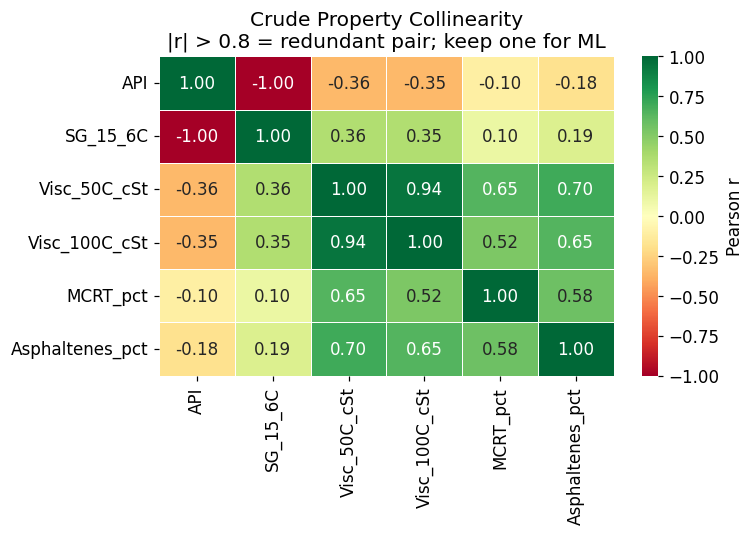

Highly collinear crude property pairs (|r| > 0.80):
  API                  vs SG_15_6C            : r = -1.000  → drop one
  Visc_50C_cSt         vs Visc_100C_cSt       : r = 0.944  → drop one


In [16]:
# ── 5b. Collinearity check — correlation between crude properties ─────────────
if len(CRUDE_COLS) >= 3:
    crude_corr = feature_df[CRUDE_COLS].corr()
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(crude_corr, ax=ax, cmap='RdYlGn', center=0, vmin=-1, vmax=1,
                annot=True, fmt='.2f', linewidths=0.4,
                cbar_kws={'label': 'Pearson r'})
    ax.set_title('Crude Property Collinearity\n'
                 '|r| > 0.8 = redundant pair; keep one for ML')
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, '5b_crude_collinearity.png'), bbox_inches='tight')
    plt.show()

    # Flag highly collinear pairs
    print('Highly collinear crude property pairs (|r| > 0.80):')
    found = False
    for i in range(len(CRUDE_COLS)):
        for j in range(i+1, len(CRUDE_COLS)):
            r = crude_corr.iloc[i, j]
            if abs(r) > 0.80:
                print(f'  {CRUDE_COLS[i]:20s} vs {CRUDE_COLS[j]:20s}: r = {r:.3f}  → drop one')
                found = True
    if not found:
        print('  None found (all |r| ≤ 0.80 — all properties can be kept independently)')

---
## 6. Summary

### Fouling State PCA (16 HX U_relative)

| PC | Interpretation | Typical variance |
|---|---|---|
| PC1 | Plant-wide fouling level (rises after long runs) | ~40–70% |
| PC2 | Differential fouling (upstream vs. downstream HXs) | ~10–25% |
| PC3+ | Individual HX anomalies | <15% each |

### Key Insights

1. **PC1 = Plant Fouling Index** — a single number capturing overall preheat train health
2. **Crude heaviness** (low API, high Asphaltenes) correlates with elevated fouling state
3. **Operating condition PCA** separates high-throughput vs. low-throughput regimes
4. **Feature reduction for ML:**
   - `days_on_duty` → independent, keep
   - `Q`, `Tavg`, `Cp` → partially collinear (all scale with throughput), use 2–3
   - Crude: check Visc_50C vs Visc_100C collinearity; keep MCRT + Asphaltenes separately

### Recommended ML Feature Set
```
days_on_duty  (time since last clean — strongest fouling predictor)
T_avg         (temperature-driven deposition kinetics)
Q             (heat duty proxy)
Asphaltenes_pct  (fouling propensity from crude)
MCRT_pct      (coking tendency at high temperature)
API           (crude heaviness, summary indicator)
```
**Target:** `U_relative` → predict fouling level [0, 1]

→ Next: **3_model_comparison.ipynb** for ML model training